# Data Cleaning Exercise

The dataset you will be working with is from the NY bus breakdown and delay system.  Data is collected in real time, directly from the school bus staff vendors.  The data was taken from:  https://www.kaggle.com/new-york-city/ny-bus-breakdown-and-delays.

Get in your groups and do the following:

- Familiarize yourselves with the data (I recommend visiting the website providedas there is amplifying information provided and it is best to view the data from the website)
- Read the question given to your group
- Determine what information you need in order to answer the question
- Attempt to answer the question, you will likely come across some issues with the data that requires you to clean the data
- Attempt to clean the data as necessary to answer your question; you may use the class notes or the internet to search for techniques, functions, or methods that will help.
- When your Instructor indicates, drop your group's Jupyter Notebook in the D2L dropbox (about 20 minutes before class ends)

The objective of this exercise is to get you working with real-life data and practice your data cleaning skills.  You may have to make some assumptions along the way -- be sure to thinking through these decision points and be able to justify your choice.  

Additionally, you should be able to articulate what you did.  During the last 20 minutes of class, each group will have 2-3 minutes to present their question, findings, and data cleaning techniques to the class.  Specifically discuss the data cleaning issues you encountered and how you dealt with them.  Be sure to state any assumptions you made along the way.  You may use your group's Jupyter Notebook during your presentation.

**Note:**  Some questions require considerable time to get the data "clean enought" in order to answer the question at hand.  I am not concerned if you don't make it "to the end", however your group should use the time wisely, working diligently to get as much as you can out of this exercise.

## Import Pandas, load data, look at it

In [1]:
import pandas as pd
df = pd.read_csv('bus.csv')
df.head()

C:\Users\ifrommer\AppData\Local\Temp\ipykernel_18028\1216031248.py:2: DtypeWarning: Columns (0: Incident_Number) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('bus.csv')


,School_Year,Busbreakdown_ID,Run_Type,Bus_No,Route_Number,Reason,Schools_Serviced,Occurred_On,Created_On,Boro,...,How_Long_Delayed,Number_Of_Students_On_The_Bus,Has_Contractor_Notified_Schools,Has_Contractor_Notified_Parents,Have_You_Alerted_OPT,Informed_On,Incident_Number,Last_Updated_On,Breakdown_or_Running_Late,School_Age_or_PreK
0,2015-2016,1212699,Special Ed AM Run,48186,N758,Other,75485,2015-09-02T06:27:00,2015-09-02T06:29:00,Nassau County,...,25 minutes,0,Yes,No,No,2015-09-02T06:29:00,NaN,2015-09-02T06:29:16,Running Late,School-Age
1,2015-2016,1212700,Special Ed AM Run,2518,L530,Mechanical Problem,21854,2015-09-02T06:24:00,2015-09-02T06:30:00,Brooklyn,...,NaN,0,Yes,Yes,Yes,2015-09-02T06:30:00,NaN,2015-09-02T06:30:19,Breakdown,School-Age
2,2015-2016,1212701,Special Ed AM Run,235,K168,Other,18366,2015-09-02T06:45:00,2015-09-02T06:47:00,Brooklyn,...,30MINS,0,Yes,Yes,No,2015-09-02T06:47:00,NaN,2015-09-02T08:05:39,Running Late,School-Age
3,2015-2016,1212703,Special Ed AM Run,2102,K216,Other,21501,2015-09-02T06:55:00,2015-09-02T07:02:00,Brooklyn,...,20 min,1,Yes,Yes,No,2015-09-02T07:02:00,NaN,2015-09-02T07:02:01,Running Late,School-Age
4,2015-2016,1212704,Special Ed AM Run,48162,N861,Mechanical Problem,75485,2015-09-02T06:55:00,2015-09-02T07:04:00,Nassau County,...,30 min,0,Yes,Yes,No,2015-09-02T07:04:00,NaN,2015-09-02T07:04:25,Running Late,School-Age


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 288371 entries, 0 to 288370
Data columns (total 21 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   School_Year                      288371 non-null  str   
 1   Busbreakdown_ID                  288371 non-null  int64 
 2   Run_Type                         288368 non-null  str   
 3   Bus_No                           288362 non-null  str   
 4   Route_Number                     288364 non-null  str   
 5   Reason                           288369 non-null  str   
 6   Schools_Serviced                 288364 non-null  str   
 7   Occurred_On                      288371 non-null  str   
 8   Created_On                       288371 non-null  str   
 9   Boro                             274636 non-null  str   
 10  Bus_Company_Name                 288371 non-null  str   
 11  How_Long_Delayed                 252149 non-null  str   
 12  Number_Of_Students_On_The_B

In [3]:
df.iloc[230]

School_Year                                  2015-2016
Busbreakdown_ID                                1214657
Run_Type                             Special Ed AM Run
Bus_No                                           19216
Route_Number                                      M086
Reason                                   Heavy Traffic
Schools_Serviced                                 03475
Occurred_On                        2015-09-16T06:21:00
Created_On                         2015-09-16T06:34:00
Boro                                         Manhattan
Bus_Company_Name                    BORO TRANSIT, INC.
How_Long_Delayed                                25mins
Number_Of_Students_On_The_Bus                        0
Has_Contractor_Notified_Schools                    Yes
Has_Contractor_Notified_Parents                    Yes
Have_You_Alerted_OPT                                No
Informed_On                        2015-09-16T06:34:00
Incident_Number                                    NaN
Last_Updat

### Question 1:  How much time does it typically take between a bus delay/breakdown and it being reported?

The following reference may be helpful:
- https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.to_datetime.html

**Explore which columns we might use.**

In [25]:
df.columns

Index(['School_Year', 'Busbreakdown_ID', 'Run_Type', 'Bus_No', 'Route_Number',
       'Reason', 'Schools_Serviced', 'Occurred_On', 'Created_On', 'Boro',
       'Bus_Company_Name', 'How_Long_Delayed', 'Number_Of_Students_On_The_Bus',
       'Has_Contractor_Notified_Schools', 'Has_Contractor_Notified_Parents',
       'Have_You_Alerted_OPT', 'Informed_On', 'Incident_Number',
       'Last_Updated_On', 'Breakdown_or_Running_Late', 'School_Age_or_PreK'],
      dtype='str')

Some tinkering to show that the columns `Informed_On` and `Created_On` are the same thing.

In [36]:
dft = df[['Occurred_On','Created_On','Informed_On','How_Long_Delayed']]
dft['Informed-Created'] = pd.to_datetime(dft['Informed_On']) - pd.to_datetime(dft['Created_On'])
dft

,Occurred_On,Created_On,Informed_On,How_Long_Delayed,Informed-Created
0,2015-09-02T06:27:00,2015-09-02T06:29:00,2015-09-02T06:29:00,25 minutes,0 days
1,2015-09-02T06:24:00,2015-09-02T06:30:00,2015-09-02T06:30:00,NaN,0 days
2,2015-09-02T06:45:00,2015-09-02T06:47:00,2015-09-02T06:47:00,30MINS,0 days
3,2015-09-02T06:55:00,2015-09-02T07:02:00,2015-09-02T07:02:00,20 min,0 days
4,2015-09-02T06:55:00,2015-09-02T07:04:00,2015-09-02T07:04:00,30 min,0 days
...,...,...,...,...,...
288366,2019-01-18T06:00:00,2019-01-18T06:04:00,2019-01-18T06:04:00,16-30 Min,0 days
288367,2019-01-18T06:03:00,2019-01-18T06:04:00,2019-01-18T06:04:00,46-60 Min,0 days
288368,2019-01-18T06:04:00,2019-01-18T06:04:00,2019-01-18T06:04:00,46-60 Min,0 days
288369,2019-01-18T05:50:00,2019-01-18T06:05:00,2019-01-18T06:05:00,16-30 Min,0 days


In [34]:
dft['Informed-Created'].max()

Timedelta('0 days 00:00:00')

**We will take the difference between when the incident <u>occurred</u> and when it was <u>reported</u> to be the `Report_Lag` this question is interested in.**  
But first we convert these columns to `datetime` for ease of calculation. Then we had `Report_Lag` as a column in the main DataFrame `df`.

In [40]:
dft['Occurred_ts']=pd.to_datetime(dft['Occurred_On'])
dft['Created_ts']=pd.to_datetime(dft['Created_On'])
df['Report_Lag'] = dft['Created_ts'] - dft['Occurred_ts']
df.head()

,School_Year,Busbreakdown_ID,Run_Type,Bus_No,Route_Number,Reason,Schools_Serviced,Occurred_On,Created_On,Boro,...,Number_Of_Students_On_The_Bus,Has_Contractor_Notified_Schools,Has_Contractor_Notified_Parents,Have_You_Alerted_OPT,Informed_On,Incident_Number,Last_Updated_On,Breakdown_or_Running_Late,School_Age_or_PreK,Report_Lag
0,2015-2016,1212699,Special Ed AM Run,48186,N758,Other,75485,2015-09-02T06:27:00,2015-09-02T06:29:00,Nassau County,...,0,Yes,No,No,2015-09-02T06:29:00,NaN,2015-09-02T06:29:16,Running Late,School-Age,0 days 00:02:00
1,2015-2016,1212700,Special Ed AM Run,2518,L530,Mechanical Problem,21854,2015-09-02T06:24:00,2015-09-02T06:30:00,Brooklyn,...,0,Yes,Yes,Yes,2015-09-02T06:30:00,NaN,2015-09-02T06:30:19,Breakdown,School-Age,0 days 00:06:00
2,2015-2016,1212701,Special Ed AM Run,235,K168,Other,18366,2015-09-02T06:45:00,2015-09-02T06:47:00,Brooklyn,...,0,Yes,Yes,No,2015-09-02T06:47:00,NaN,2015-09-02T08:05:39,Running Late,School-Age,0 days 00:02:00
3,2015-2016,1212703,Special Ed AM Run,2102,K216,Other,21501,2015-09-02T06:55:00,2015-09-02T07:02:00,Brooklyn,...,1,Yes,Yes,No,2015-09-02T07:02:00,NaN,2015-09-02T07:02:01,Running Late,School-Age,0 days 00:07:00
4,2015-2016,1212704,Special Ed AM Run,48162,N861,Mechanical Problem,75485,2015-09-02T06:55:00,2015-09-02T07:04:00,Nassau County,...,0,Yes,Yes,No,2015-09-02T07:04:00,NaN,2015-09-02T07:04:25,Running Late,School-Age,0 days 00:09:00


Some clean-up is required as it seems like a couple of days are over a year long, which is highly implausible.  
Let's find the max of this column and delete any rows with it.

In [59]:
max_report_lag = df['Report_Lag'].max()
print(max_report_lag)

365 days 00:05:00


In [60]:
max_report_lag_rows = df[df['Report_Lag'] == max_report_lag]
max_report_lag_rows

,School_Year,Busbreakdown_ID,Run_Type,Bus_No,Route_Number,Reason,Schools_Serviced,Occurred_On,Created_On,Boro,...,Number_Of_Students_On_The_Bus,Has_Contractor_Notified_Schools,Has_Contractor_Notified_Parents,Have_You_Alerted_OPT,Informed_On,Incident_Number,Last_Updated_On,Breakdown_or_Running_Late,School_Age_or_PreK,Report_Lag
135836,2015-2016,1350754,Special Ed AM Run,2573,Q153,Heavy Traffic,30010,2016-05-19T13:43:00,2017-05-19T13:48:00,Queens,...,0,Yes,Yes,Yes,2017-05-19T13:48:00,NaN,2017-05-19T13:48:50,Running Late,School-Age,365 days 00:05:00
283026,2017-2018,1503707,General Ed AM Run,2346,K1999,Other,"19005,23323",2018-01-07T06:44:00,2019-01-07T06:49:00,Brooklyn,...,0,No,No,No,2019-01-07T06:49:00,NaN,1900-01-01T00:00:00,Running Late,School-Age,365 days 00:05:00


In [61]:
max_report_lag_rows.index

RangeIndex(start=135836, stop=430216, step=147190)

In [62]:
new_df = df.drop(max_report_lag_rows.index, axis = 0)    # axis = 0 signifies dropping rows

In [63]:
new_df['Report_Lag'].max()

Timedelta('28 days 08:40:00')

The max is still unrealistically high.  We could keep whittling it down by removing obviously large values.  Instead we will report the the median since it will give less weight to those outliers.

In [72]:
lag_median = new_df['Report_Lag'].median()
print(lag_median)

0 days 00:03:00


In [74]:
lag_median.total_seconds()

180.0

**So that's 3 minutes.**

### Question 2: On average, how long are the bus delays/breakdowns?

In [77]:
hld = df['How_Long_Delayed']
hld

0         25 minutes
1                NaN
2             30MINS
3             20 min
4             30 min
             ...    
288366     16-30 Min
288367     46-60 Min
288368     46-60 Min
288369     16-30 Min
288370     31-45 Min
Name: How_Long_Delayed, Length: 288371, dtype: str

So this column has the necessary information, but the values are stored in various formats.  Let's try to find the most common formats. We can see from the above printout that there are 288,371 entries.

In [78]:
# These ones look like ranges with "-" in middle
hld_ranges = [i for i in hld if '-' in str(i) and 'm' not in str(i).lower()]
len(hld_ranges)

2710

There aren't very many (2,710 out of 288,371).
How about ones with "min" or similar in them?

In [84]:
with_min = [i for i in hld if 'min' in str(i).lower()]
print('total with minutes = ',len(with_min))

total with minutes =  233909


Ok, lots of those.  We will go with those.  
How many also have 'h' from some form of the word 'hours' in them?

In [85]:
h_and_min = [i for i in with_min if 'h' in str(i).lower()]
len(h_and_min)

198

Not too many.  Note they seem to come in two forms: hour appearing first or second.

In [86]:
print(h_and_min[:10])

['45min/1hr', '45mins 1hr', '45mins 1hr', '1hr/30min', '1hr/30min', '1hour45min', '45min/1hr', '45min/1hr', '1HR 30 MIN', '1H15MIN']


So one approach would be to divide these into hours first then minutes and vice versa.  
Then parse and convert to minutes.
Use of regexp would be helpful.
On the other hand, there aren't that many.

Instead, let's focus on the large group with just minutes for now using `regexp`.

In [87]:
# This pattern looks for sequences of some number of digits then blank space then 'h' then more blank space and possibly other characters.
pat0 = r'\d+( )*h( )*'
S=df.How_Long_Delayed.str.match(pat0)
df[S==True]['How_Long_Delayed']

28              1hr
33              1hr
53             1 hr
161             1hr
170          1 hour
            ...    
149063       1 hour
149079       1 hour
149339          1hr
149360    1hr 30min
149550       1 hour
Name: How_Long_Delayed, Length: 1954, dtype: str

In [89]:
# This pattern says look for entries with some number of digits followed by 0 or more spaces, then the letters "min", then possibly more spaces.
pat2 = r'\d+( )min( )'
pat2

'\\d+( )min( )'

In [90]:
# Here are the results:
pat2 = r'\d+( )*min( )*'
S=df.How_Long_Delayed.str.match(pat2)
df[S==True]['How_Long_Delayed']

0         25 minutes
3             20 min
4             30 min
10           30 mins
13           15 mins
             ...    
149707        30 min
149713        20 min
149714        20 min
149725         25min
149729         45min
Name: How_Long_Delayed, Length: 42036, dtype: str

This next block of code does essential the same thing except it stores the number portion in a column of a new data frame we label S.

In [91]:
pat3 = r'(?P<minutes>\d+)(?P<mid_space>( )*)(?P<min_word>min( )*)'
S=df.How_Long_Delayed.str.extract(pat3)
S.head()

,minutes,mid_space,2,min_word,4
0,25,,,min,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,20,,,min,NaN
4,30,,,min,NaN


In [ ]:
#df[S==True]['How_Long_Delayed']

In [92]:
# Extract just the minutes and drop any with blank values
sm = S['minutes'].dropna()
sm

0         25
3         20
4         30
10        30
13        15
          ..
149714    20
149725    25
149726    60
149727    30
149729    45
Name: minutes, Length: 49924, dtype: str

In [93]:
# Then take the mean of these minutes values
import numpy as np
round(np.mean([int(i) for i in sm]),2)   # values in sm are strings, so converting to int

np.float64(25.42)

So this is only a rough estimate and is bound to be low since we ignored any entries with 'h' in them, which will be longer.
But it starts off the idea of how we can handle these.  We can apply a similar process to other kinds of patterns we see in this column.

### Question 3: How many delays/breakdowns did First Steps Bus Company have during the 2016-2017 versus the 2017-2018 school year?

Get a sense of which names were used:

In [94]:
[i for i in list(df['Bus_Company_Name'].unique()) if 'STEPS' in i.upper()]

['FIRST STEPS TRANSP INC. (',
 'FIRST STEPS',
 'FIRST STEPS TRANSP INC. (B2192)',
 'FIRST STEPS TRANS INC. (B2192)',
 'FIRST STEPS TRANS, INC']

In [95]:
tmp = [i for i in list(df['Bus_Company_Name'].unique()) if 'FIRST' in i]
tmp

['TWENTY FIRST AV TRANSP (B',
 'FIRST STEPS TRANSP INC. (',
 'FIRST STEPS',
 'FIRST STEPS TRANSP INC. (B2192)',
 'TWENTY FIRST AV TRANSP (B2192)',
 'FIRST STEPS TRANS INC. (B2192)',
 'FIRST STEPS TRANS, INC']

In [97]:
firstStepsNames = tmp[1:4] + tmp[-2:]
firstStepsNames

['FIRST STEPS TRANSP INC. (',
 'FIRST STEPS',
 'FIRST STEPS TRANSP INC. (B2192)',
 'FIRST STEPS TRANS INC. (B2192)',
 'FIRST STEPS TRANS, INC']

In [98]:
# Data frame with only FIRST STEPS (and variations on that name) in it
first_steps_only = df[df['Bus_Company_Name'].isin(firstStepsNames)]
first_steps_only

,School_Year,Busbreakdown_ID,Run_Type,Bus_No,Route_Number,Reason,Schools_Serviced,Occurred_On,Created_On,Boro,...,Number_Of_Students_On_The_Bus,Has_Contractor_Notified_Schools,Has_Contractor_Notified_Parents,Have_You_Alerted_OPT,Informed_On,Incident_Number,Last_Updated_On,Breakdown_or_Running_Late,School_Age_or_PreK,Report_Lag
318,2015-2016,1214347,Special Ed AM Run,2900,Q190,Flat Tire,24088,2015-09-11T06:25:00,2015-09-11T08:02:00,Queens,...,0,Yes,Yes,Yes,2015-09-11T08:02:00,NaN,2015-09-11T08:02:28,Running Late,School-Age,0 days 01:37:00
403,2015-2016,1215158,Special Ed PM Run,1317,Q876,Other,26187,2015-09-16T14:35:00,2015-09-16T14:49:00,Queens,...,2,Yes,Yes,Yes,2015-09-16T14:49:00,NaN,2015-09-16T14:49:36,Running Late,School-Age,0 days 00:14:00
1121,2015-2016,1213573,Special Ed AM Run,118,R833,Mechanical Problem,31905,2015-09-09T16:30:00,2015-09-09T17:03:00,Staten Island,...,3,Yes,No,Yes,2015-09-09T17:03:00,NaN,2015-09-09T17:03:35,Breakdown,School-Age,0 days 00:33:00
1338,2015-2016,1216822,Special Ed AM Run,FR 1515,W827,Other,75944,2015-09-24T06:55:00,2015-09-24T07:26:00,Westchester,...,0,Yes,Yes,Yes,2015-09-24T07:26:00,NaN,2015-09-24T07:26:23,Running Late,School-Age,0 days 00:31:00
1427,2015-2016,1216441,Special Ed AM Run,1002,P880,Mechanical Problem,26046,2015-09-21T14:50:00,2015-09-21T14:55:00,Manhattan,...,0,Yes,Yes,Yes,2015-09-21T14:55:00,NaN,2015-09-21T14:55:28,Breakdown,School-Age,0 days 00:05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288135,2018-2019,1508638,Special Ed AM Run,1336,M439,Heavy Traffic,03896,2019-01-17T08:46:00,2019-01-17T08:49:00,Manhattan,...,0,Yes,Yes,Yes,2019-01-17T08:49:00,NaN,1900-01-01T00:00:00,Running Late,School-Age,0 days 00:03:00
288279,2018-2019,1508782,Pre-K/EI,2641,HK4,Other,C268,2019-01-17T14:08:00,2019-01-17T14:10:00,Brooklyn,...,0,Yes,Yes,Yes,2019-01-17T14:10:00,NaN,1900-01-01T00:00:00,Running Late,Pre-K,0 days 00:02:00
288290,2018-2019,1508793,Special Ed PM Run,1362,M455,Heavy Traffic,"02647,02991",2019-01-17T14:22:00,2019-01-17T14:30:00,Manhattan,...,0,Yes,Yes,Yes,2019-01-17T14:30:00,NaN,2019-01-17T14:40:41,Running Late,School-Age,0 days 00:08:00
288296,2018-2019,1508799,Special Ed PM Run,1306,M090,Flat Tire,"06462,06467",2019-01-17T14:35:00,2019-01-17T14:37:00,Manhattan,...,0,Yes,Yes,Yes,2019-01-17T14:37:00,NaN,1900-01-01T00:00:00,Running Late,School-Age,0 days 00:02:00


In [99]:
first_steps_only['Bus_Company_Name'].unique()

<StringArray>
[      'FIRST STEPS TRANSP INC. (',                     'FIRST STEPS',
 'FIRST STEPS TRANSP INC. (B2192)',  'FIRST STEPS TRANS INC. (B2192)',
          'FIRST STEPS TRANS, INC']
Length: 5, dtype: str

In [100]:
first_steps_only.info()

<class 'pandas.DataFrame'>
Index: 4948 entries, 318 to 288297
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype          
---  ------                           --------------  -----          
 0   School_Year                      4948 non-null   str            
 1   Busbreakdown_ID                  4948 non-null   int64          
 2   Run_Type                         4947 non-null   str            
 3   Bus_No                           4948 non-null   str            
 4   Route_Number                     4948 non-null   str            
 5   Reason                           4948 non-null   str            
 6   Schools_Serviced                 4948 non-null   str            
 7   Occurred_On                      4948 non-null   str            
 8   Created_On                       4948 non-null   str            
 9   Boro                             4896 non-null   str            
 10  Bus_Company_Name                 4948 non-null   str        

Next could either use groupby or else filter to get df's for those two years
Then compare sizes.

In [101]:
g = first_steps_only.groupby('School_Year')
g.size()

School_Year
2015-2016     990
2016-2017    1779
2017-2018    1392
2018-2019     787
dtype: int64

### Question 4:  What bus company had the most Mechanical Problems in this dataset?

In [109]:
# practice '25
dfm = df[df.Reason == 'Mechanical Problem']
dfmg = dfm.groupby('Bus_Company_Name')
ds = dfmg.size()
ds

Bus_Company_Name
1967                              1
1992                              8
ACME BUS CORP. (B2321)          119
ADDIES                           10
ALINA SERVICES CORP.             66
                               ... 
VINNY`S BUS SERVICES (B2321)      9
Y & M TRANSIT CORP (B2192       384
Y & M TRANSIT CORP (B2192)      639
Y & M TRANSIT CORP (B2321        28
Y & M TRANSIT CORP (B2321)        3
Length: 102, dtype: int64

In [112]:
ds.sort_values(ascending=False)

Bus_Company_Name
BORO TRANSIT, INC.                     2676
LITTLE RICHIE BUS SERVICE              2268
SNT BUS INC                            2221
JOFAZ TRANSPORTATION INC.              1363
RELIANT TRANS, INC. (B232              1186
                                       ... 
VINNY`S BUS SERVICES (B23                 3
MONTAUK STUDENT TRANS, INC. (B2321)       2
SAFE COACH INC.                           2
ALL COUNTY BUS LLC (B2321)                1
1967                                      1
Length: 102, dtype: int64

It looks like we're done, but the problem is many bus company names appear multiple times with various spellings.  Let's loop through the beginning of the alphabet to get a sense.

In [115]:
from string import ascii_uppercase
for l in ascii_uppercase[:5]:
    for i in ds.index:
        if i[0] == l:
            print(i,ds[i])
    print()

ACME BUS CORP. (B2321) 119
ADDIES 10
ALINA SERVICES CORP. 66
ALL AMERICAN SCHOOL BUS C 185
ALL AMERICAN SCHOOL BUS CORP. 118
ALL COUNTY BUS LLC (B2321) 1
ALLIED TRANSIT CORP. 265
ANOTHER RIDE INC. 13

B & F SKILLED INC.(B2192) 78
BOBBY`S BUS CO. INC. 802
BORO TRANSIT, INC. 2676

CAREFUL BUS 66
CAREFUL BUS SERVICE INC ( 10
CAREFUL BUS SERVICE INC (B2192) 7
CHILDREN`S TRANS INC. (B2 30
CHILDREN`S TRANS INC. (B2321) 14
CONSOLIDATED BUS TRANS. I 375
CONSOLIDATED BUS TRANS. INC. 161
CONSOLIDATED BUS TRANSIT, INC. 100

DON THOMAS BUSES, INC. 61
DON THOMAS BUSES, INC. (B 138
DON THOMAS BUSES, INC. (B2321) 266

EMPIRE CHARTER SERVICE IN 33
EMPIRE CHARTER SERVICE INC 58
EMPIRE STATE BUS CORP. 111



Plan:
- combine names that are the same company similar to question 3.
- filter to select reason = mech problem
- use groupby by company
- then probably use sizes of the groups

### Question 5:  How many incidents are recorded where more than one school is affected by a bus delay or breakdown?

After exploring the columns, we find that `Schools_Serviced` is the column we need for this question. Looking at it we can see that some of its entries have numerous schools listed.

In [117]:
df.Schools_Serviced

0                     75485
1                     21854
2                     18366
3                     21501
4                     75485
                ...        
288366          20200,20229
288367    02655,02667,02908
288368          06100,06211
288369          01817,02878
288370    03002,03689,03931
Name: Schools_Serviced, Length: 288371, dtype: str

A cursory inspection reveals that entries with multiple schools contain commas. We will use that to determine the answer to this question, though a more thorough investigation should be completed.

In [124]:
dfl = df.Schools_Serviced.to_list()

In [132]:
# We will capture # of entries with commans or spaces.
dfl2 = [i for i in dfl if ',' in str(i) or ' ' in str(i) or '  ' in str(i)]
print(len(dfl2))

93581


First, a little testing to see how we can convert a comma-separated string into a list, removing any blank entries

In [ ]:
x = '113,115'
u = '88,'
print(x.split(','))
print(u.split(','))

In [ ]:
ul = ['88', '']
[i for i in ul if i]

Now create a function to apply to the Schools_Serviced column to obtain Num_Schools serviced.

In [126]:
def numItems(inp):
    tmpList = str(inp).split(',')
    inpList = [i for i in tmpList if i]
    return len(inpList)

In [87]:
numItems('af,sd,ss')

3

In [127]:
df['Num_Schools'] = df['Schools_Serviced'].apply(numItems)
df

,School_Year,Busbreakdown_ID,Run_Type,Bus_No,Route_Number,Reason,Schools_Serviced,Occurred_On,Created_On,Boro,...,Has_Contractor_Notified_Schools,Has_Contractor_Notified_Parents,Have_You_Alerted_OPT,Informed_On,Incident_Number,Last_Updated_On,Breakdown_or_Running_Late,School_Age_or_PreK,Report_Lag,Num_Schools
0,2015-2016,1212699,Special Ed AM Run,48186,N758,Other,75485,2015-09-02T06:27:00,2015-09-02T06:29:00,Nassau County,...,Yes,No,No,2015-09-02T06:29:00,NaN,2015-09-02T06:29:16,Running Late,School-Age,0 days 00:02:00,1
1,2015-2016,1212700,Special Ed AM Run,2518,L530,Mechanical Problem,21854,2015-09-02T06:24:00,2015-09-02T06:30:00,Brooklyn,...,Yes,Yes,Yes,2015-09-02T06:30:00,NaN,2015-09-02T06:30:19,Breakdown,School-Age,0 days 00:06:00,1
2,2015-2016,1212701,Special Ed AM Run,235,K168,Other,18366,2015-09-02T06:45:00,2015-09-02T06:47:00,Brooklyn,...,Yes,Yes,No,2015-09-02T06:47:00,NaN,2015-09-02T08:05:39,Running Late,School-Age,0 days 00:02:00,1
3,2015-2016,1212703,Special Ed AM Run,2102,K216,Other,21501,2015-09-02T06:55:00,2015-09-02T07:02:00,Brooklyn,...,Yes,Yes,No,2015-09-02T07:02:00,NaN,2015-09-02T07:02:01,Running Late,School-Age,0 days 00:07:00,1
4,2015-2016,1212704,Special Ed AM Run,48162,N861,Mechanical Problem,75485,2015-09-02T06:55:00,2015-09-02T07:04:00,Nassau County,...,Yes,Yes,No,2015-09-02T07:04:00,NaN,2015-09-02T07:04:25,Running Late,School-Age,0 days 00:09:00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288366,2018-2019,1508869,General Ed AM Run,25573,K2021,Mechanical Problem,"20200,20229",2019-01-18T06:00:00,2019-01-18T06:04:00,Brooklyn,...,No,No,No,2019-01-18T06:04:00,NaN,1900-01-01T00:00:00,Running Late,School-Age,0 days 00:04:00,2
288367,2018-2019,1508870,Special Ed AM Run,1809,M505,Heavy Traffic,"02655,02667,02908",2019-01-18T06:03:00,2019-01-18T06:04:00,Manhattan,...,Yes,Yes,No,2019-01-18T06:04:00,NaN,1900-01-01T00:00:00,Running Late,School-Age,0 days 00:01:00,3
288368,2018-2019,1508871,Special Ed AM Run,1922,M535,Heavy Traffic,"06100,06211",2019-01-18T06:04:00,2019-01-18T06:04:00,Manhattan,...,Yes,Yes,No,2019-01-18T06:04:00,NaN,1900-01-01T00:00:00,Running Late,School-Age,0 days 00:00:00,2
288369,2018-2019,1508872,General Ed AM Run,28765,M1119,Other,"01817,02878",2019-01-18T05:50:00,2019-01-18T06:05:00,Manhattan,...,Yes,No,No,2019-01-18T06:05:00,NaN,1900-01-01T00:00:00,Running Late,School-Age,0 days 00:15:00,2


In [128]:
df['Num_Schools'].value_counts()

Num_Schools
1     195136
2      44665
3      28080
4      12543
5       4576
6       1620
7        774
8        496
9        269
10       103
11        66
12        26
13        14
14         3
Name: count, dtype: int64

In [129]:
# Getting all values greater than 1.
sum(df['Num_Schools'].value_counts()[1:])

93235

Just inspecting those three with 14 schools.

In [130]:
df[df['Num_Schools']==14]

,School_Year,Busbreakdown_ID,Run_Type,Bus_No,Route_Number,Reason,Schools_Serviced,Occurred_On,Created_On,Boro,...,Has_Contractor_Notified_Schools,Has_Contractor_Notified_Parents,Have_You_Alerted_OPT,Informed_On,Incident_Number,Last_Updated_On,Breakdown_or_Running_Late,School_Age_or_PreK,Report_Lag,Num_Schools
162671,2017-2018,1377645,General Ed AM Run,21960,X9532,Heavy Traffic,"08107,08130,08140,08146,08182,08301,08444,0854...",2017-10-17T03:16:00,2017-10-17T15:33:00,Bronx,...,Yes,No,No,2017-10-17T15:33:00,NaN,1900-01-01T00:00:00,Running Late,School-Age,0 days 12:17:00,14
162676,2017-2018,1377650,General Ed PM Run,21960,X9532,Heavy Traffic,"08107,08130,08140,08146,08182,08301,08444,0854...",2017-10-17T14:30:00,2017-10-17T15:50:00,Bronx,...,Yes,No,No,2017-10-17T15:50:00,NaN,1900-01-01T00:00:00,Running Late,School-Age,0 days 01:20:00,14
215128,2017-2018,1430994,General Ed PM Run,28760,K9490,Delayed by School,"20030,20102,20104,20160,20176,20179,20180,2020...",2018-04-20T14:40:00,2018-04-20T14:57:00,Brooklyn,...,Yes,No,No,2018-04-20T14:57:00,NaN,2018-04-20T14:57:13,Running Late,School-Age,0 days 00:17:00,14


### Question 6:  What are the number of occurrences, by month, that a delay is caused by Heavy Traffic?  Display this using a bar chart

The following reference may be helpful:
- https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.to_datetime.html

Extract the rows with "Heavy Traffic" as reason into a new DataFrame.  
Create a new "Month" column for this DataFrame siginifying the month of the occurrence.

In [135]:
dfht = df[df.Reason == 'Heavy Traffic']
dfht['Month'] = [i.month for i in pd.to_datetime(dfht['Occurred_On'])]
dfht.Month

6         9
9         9
10        9
11        9
13        9
         ..
288364    1
288365    1
288367    1
288368    1
288370    1
Name: Month, Length: 178038, dtype: int64

Next group by "Month" and bar-plot the group sizes.

<Axes: xlabel='Month'>

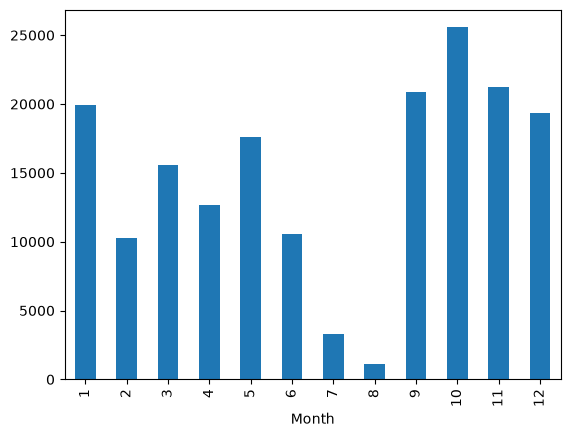

In [136]:
htg = dfht.groupby('Month')
htg.size().plot(kind='bar')